# Exploración de datos NUMBAT

**Objetivo:** entender la estructura real de los archivos NUMBAT descargados.

Decisiones que dependen de esta exploración:
- Split train/test (opciones A, B o C).
- Features para el modelo.
- Si limitar a Tube o incluir DLR / Overground / Elizabeth Line.
- Nomenclatura de estación en la API (código vs nombre).
- Umbrales para Bajo/Medio/Alto/Saturado.

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (12, 5)

RAIZ = Path.cwd()
if RAIZ.name == 'notebooks':
    RAIZ = RAIZ.parent
DATA_RAW = RAIZ / 'data' / 'raw'

print(f'Raíz del proyecto: {RAIZ}')
print(f'Carpeta de datos:  {DATA_RAW}')
print(f'¿Existe?           {DATA_RAW.exists()}')

Raíz del proyecto: c:\Users\juan_\Desktop\Proyecto_p\Proyecto_productivizacion
Carpeta de datos:  c:\Users\juan_\Desktop\Proyecto_p\Proyecto_productivizacion\data\raw
¿Existe?           True


## 1. Inventario de archivos descargados

In [3]:
archivos = sorted(DATA_RAW.rglob('*.xlsx'))
print(f'Total de archivos: {len(archivos)}\n')
for a in archivos:
    tam_mb = a.stat().st_size / 1_000_000
    print(f'  {a.relative_to(DATA_RAW)}  ({tam_mb:.1f} MB)')

Total de archivos: 19

  2017\NBT17MTT_Outputs.xlsx  (11.1 MB)
  2017\NBT17SAT_Outputs.xlsx  (11.1 MB)
  2017\NBT17SUN_Outputs.xlsx  (10.3 MB)
  2019\NBT19_Definitions_Published.xlsx  (0.4 MB)
  2019\NBT19FRI_Outputs.xlsx  (9.9 MB)
  2019\NBT19MTT_Outputs.xlsx  (9.8 MB)
  2019\NBT19SAT_Outputs.xlsx  (9.8 MB)
  2019\NBT19SUN_Outputs.xlsx  (9.2 MB)
  2023\NBT23FRI_outputs.xlsx  (12.1 MB)
  2023\NBT23MON_outputs.xlsx  (11.8 MB)
  2023\NBT23SAT_outputs.xlsx  (12.0 MB)
  2023\NBT23SUN_outputs.xlsx  (11.2 MB)
  2023\NBT23TWT_outputs.xlsx  (11.8 MB)
  2024\NBT24FRI_outputs.xlsx  (12.4 MB)
  2024\NBT24MON_outputs.xlsx  (12.1 MB)
  2024\NBT24SAT_outputs.xlsx  (12.3 MB)
  2024\NBT24SUN_outputs.xlsx  (11.6 MB)
  2024\NBT24TWT_outputs.xlsx  (12.1 MB)
  2024\PTSP Oasis for NUMBAT definitions.xlsx  (6.2 MB)


## 2. ¿Qué hojas trae un archivo NUMBAT?

Cogemos un Excel de 2024 y listamos sus hojas.

In [4]:
EJEMPLO = DATA_RAW / '2024' / 'NBT24TWT_outputs.xlsx'
assert EJEMPLO.exists(), f'No existe: {EJEMPLO}'

xls = pd.ExcelFile(EJEMPLO)
print(f'Archivo: {EJEMPLO.name}')
print(f'Hojas disponibles ({len(xls.sheet_names)}):')
for nombre in xls.sheet_names:
    print(f'  - {nombre}')

Archivo: NBT24TWT_outputs.xlsx
Hojas disponibles (10):
  - _Cover
  - LineLookUp
  - Link_Loads
  - Link_Frequencies
  - Line_Boarders
  - Station_Flows
  - Station_Entries
  - Station_Exits
  - Station_Boarders
  - Station_Alighters


### 2.1. Cabecera de cada hoja

In [5]:
for nombre in xls.sheet_names:
    print(f'\n{"="*70}')
    print(f'HOJA: {nombre}')
    print('=' * 70)
    try:
        df = pd.read_excel(EJEMPLO, sheet_name=nombre, nrows=5)
        print(f'Forma (primeras 5 filas): {df.shape}')
        print(f'Primeras columnas: {df.columns.tolist()[:12]}')
        display(df.head(3))
    except Exception as exc:
        print(f'Error leyendo la hoja: {exc}')


HOJA: _Cover
Forma (primeras 5 filas): (5, 4)
Primeras columnas: ['Unnamed: 0', 'Transport for London NUMBAT for LU/LO/DLR/Elizabeth Line', 'Unnamed: 2', 'Unnamed: 3']


,Unnamed: 0,Transport for London NUMBAT for LU/LO/DLR/Elizabeth Line,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,NaN,TfL - Public Transport Service Planning,NaN,NaN
2,NaN,SMBRailDemandQueries@tfl.gov.uk,NaN,NaN



HOJA: LineLookUp
Forma (primeras 5 filas): (5, 2)
Primeras columnas: ['OldLineCode', 'LineCode']


,OldLineCode,LineCode
0,BAK,BAK
1,CEN,CEN
2,DIS,DIS



HOJA: Link_Loads
Forma (primeras 5 filas): (5, 113)
Primeras columnas: ['Link Loads', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']


...

,Station Exits,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,hour (hr),5,5.1,5.2,5.3,6,6.1,6.2,6.3,7,7.1,7.2,7.3,8,8.1,8.2,8.3,9,9.1,9.2,...,21.2,21.3,22,22.1,22.2,22.3,23,23.1,23.2,23.3,24,24.1,24.2,24.3,25,25.1,25.2,25.3,26,26.1,26.2,26.3,27,27.1,27.2,27.3,28,28.1,28.2,28.3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,quarter hour (qhr),21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116
1,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,Late,0500-0515,0515-0530,0530-0545,0545-0600,0600-0615,0615-0630,0630-0645,0645-0700,0700-0715,0715-0730,0730-0745,0745-0800,0800-0815,0815-0830,0830-0845,0845-0900,0900-0915,0915-0930,0930-0945,...,2130-2145,2145-2200,2200-2215,2215-2230,2230-2245,2245-2300,2300-2315,2315-2330,2330-2345,2345-0000,0000-0015,0015-0030,0030-0045,0045-0100,0100-0115,0115-0130,0130-0145,0145-0200,0200-0215,0215-0230,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
2,750,ABRd,Abbey Road,2/3,2099.115616,96.537928,488.453534,499.542763,537.407551,246.272814,230.901025,0.27809,2.031372,4.91022,8.744421,13.470968,17.662873,22.18675,27.253235,29.381897,37.98075,46.841064,51.222157,56.130698,59.654862,52.149441,44.315759,38.418047,28.277356,22.445285,...,18.852394,18.565565,18.8912,18.817938,18.096495,17.189597,16.219567,15.097388,14.817422,16.785399,17.087203,22.254048,19.973355,16.825015,10.886275,7.960124,0,0,0,0,0,0,0,0,0,0,0,0,0,0



HOJA: Station_Boarders
Forma (primeras 5 filas): (5, 111)
Primeras columnas: ['Station Boarders', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']


,Station Boarders,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,hour (hr),5,5.1,5.2,5.3,6,6.1,6.2,6.3,7,7.1,7.2,7.3,8,8.1,8.2,...,21.2,21.3,22,22.1,22.2,22.3,23,23.1,23.2,23.3,24,24.1,24.2,24.3,25,25.1,25.2,25.3,26,26.1,26.2,26.3,27,27.1,27.2,27.3,28,28.1,28.2,28.3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,quarter hour (qhr),21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,...,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116
1,ID,NLC,ASC,Station,Mode,Line,Dir,Platform,Total,Early,AM Peak,Midday,PM Peak,Evening,Late,0500-0515,0515-0530,0530-0545,0545-0600,0600-0615,0615-0630,0630-0645,0645-0700,0700-0715,0715-0730,0730-0745,0745-0800,0800-0815,0815-0830,0830-0845,...,2130-2145,2145-2200,2200-2215,2215-2230,2230-2245,2245-2300,2300-2315,2315-2330,2330-2345,2345-0000,0000-0015,0015-0030,0030-0045,0045-0100,0100-0115,0115-0130,0130-0145,0145-0200,0200-0215,0215-0230,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
2,111091,750,ABRd,Abbey Road,DLR,DLR,IB,DLR // IB,1615.92503,99.225137,502.33909,394.91147,424.582064,145.009322,49.857946,1.652736,2.907904,6.554573,9.486801,11.842518,17.640229,24.528252,24.612124,32.103358,42.100137,43.993115,51.662737,56.039883,53.376812,48.609086,...,7.214399,6.825849,6.103328,6.882037,6.148446,6.034603,6.011724,5.094158,5.000768,3.479001,2.483612,1.40674,1.2135,0.00003,0.000002,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



HOJA: Station_Alighters
Forma (primeras 5 filas): (5, 111)
Primeras columnas: ['Station Alighters', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']


,Station Alighters,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,hour (hr),5,5.1,5.2,5.3,6,6.1,6.2,6.3,7,7.1,7.2,7.3,8,8.1,8.2,...,21.2,21.3,22,22.1,22.2,22.3,23,23.1,23.2,23.3,24,24.1,24.2,24.3,25,25.1,25.2,25.3,26,26.1,26.2,26.3,27,27.1,27.2,27.3,28,28.1,28.2,28.3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,quarter hour (qhr),21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,...,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116
1,ID,NLC,ASC,Station,Mode,Line,Dir,Platform,Total,Early,AM Peak,Midday,PM Peak,Evening,Late,0500-0515,0515-0530,0530-0545,0545-0600,0600-0615,0615-0630,0630-0645,0645-0700,0700-0715,0715-0730,0730-0745,0745-0800,0800-0815,0815-0830,0830-0845,...,2130-2145,2145-2200,2200-2215,2215-2230,2230-2245,2245-2300,2300-2315,2315-2330,2330-2345,2345-0000,0000-0015,0015-0030,0030-0045,0045-0100,0100-0115,0115-0130,0130-0145,0145-0200,0200-0215,0215-0230,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
2,111091,750,ABRd,Abbey Road,DLR,DLR,IB,DLR // IB,754.938317,51.809868,168.474216,213.721932,145.136672,106.282371,69.513259,0.172295,1.629154,3.306889,5.893701,7.883293,10.401467,11.445605,11.077464,10.661374,13.231345,13.127046,16.792083,20.50069,20.704146,19.084641,...,7.66659,7.734496,7.702352,7.632444,7.967635,7.518489,7.381056,6.694582,6.572739,5.127761,4.895055,3.182696,2.577915,1.507109,0.753426,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 3. Profundizar en `Station_Entries`

**Estructura descubierta:** NUMBAT trae **3 filas de cabecera apiladas**:
- Fila 0: etiquetas-paraguas (`Station Entries`, `hour (hr)`).
- Fila 1: sub-etiquetas (números de hora 5..28, índices qhr 21..116).
- Fila 2: **nombres reales** de columna (`NLC`, `ASC`, `Station`, `Fare Zone`, `Total`, `Early`, `AM Peak`, `Midday`, `PM Peak`, `Evening`, `Late`, `0500-0515`, ... `0445-0500`).

Leemos con `header=2` para que pandas use la tercera fila como cabecera y descarte las dos primeras.

In [6]:
HOJA_OBJETIVO = 'Station_Entries'
FILA_CABECERA = 2

df_entry = pd.read_excel(EJEMPLO, sheet_name=HOJA_OBJETIVO, header=FILA_CABECERA)
print(f'Forma de {HOJA_OBJETIVO}: {df_entry.shape}')
print(f'Número de columnas: {len(df_entry.columns)}')
print(f'\nPrimeras columnas: {df_entry.columns[:20].tolist()}')
print(f'\nÚltimas columnas:  {df_entry.columns[-10:].tolist()}')

Forma de Station_Entries: (471, 107)
Número de columnas: 107

Primeras columnas: ['NLC', 'ASC', 'Station', 'Fare Zone', 'Total', 'Early', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Late', '0500-0515', '0515-0530', '0530-0545', '0545-0600', '0600-0615', '0615-0630', '0630-0645', '0645-0700', '0700-0715']

Últimas columnas:  ['0230-0245', '0245-0300', '0300-0315', '0315-0330', '0330-0345', '0345-0400', '0400-0415', '0415-0430', '0430-0445', '0445-0500']


In [7]:
df_entry.head(10)

,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,Late,0500-0515,0515-0530,0530-0545,0545-0600,0600-0615,0615-0630,0630-0645,0645-0700,0700-0715,0715-0730,0730-0745,0745-0800,0800-0815,0815-0830,0830-0845,0845-0900,0900-0915,0915-0930,0930-0945,...,2130-2145,2145-2200,2200-2215,2215-2230,2230-2245,2245-2300,2300-2315,2315-2330,2330-2345,2345-0000,0000-0015,0015-0030,0030-0045,0045-0100,0100-0115,0115-0130,0130-0145,0145-0200,0200-0215,0215-0230,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
0,750,ABRd,Abbey Road,2/3,2345.280009,182.042948,646.670023,668.323560,530.264648,221.563040,96.415790,2.888792,8.350592,12.750357,18.752986,25.745682,33.224980,37.396422,42.933136,47.335227,54.193645,65.708186,68.289784,68.496366,70.868313,61.863253,51.840330,48.924392,42.033768,33.468066,...,12.645746,11.008208,11.098477,11.029926,9.689882,8.888077,9.205629,7.844178,8.280411,6.463938,7.413629,5.857865,4.860611,3.107350,2.675816,3.485525e-07,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,1404,ACCr,Acton Central,3,2761.331050,198.234129,878.501138,702.676372,682.260026,223.385872,76.273514,0.000000,0.000000,6.949193,20.123085,28.378528,35.720886,49.191123,57.871314,67.021587,75.029218,87.513128,98.579753,99.919852,88.945093,84.098491,78.528338,62.021725,51.725715,47.073548,...,12.483793,13.041531,14.333273,14.070048,13.830012,11.354864,8.986202,6.012120,4.072733,2.170425,1.010542,0.403955,0.029341,0.000000,0.000000,0.000000e+00,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,3000,AMLr,Acton Main Line,3,5804.078852,423.492231,2176.385382,1595.639283,1227.711629,306.099393,74.750934,9.643206,17.136119,26.181957,37.591872,53.818733,76.187723,91.369317,111.563304,131.793971,162.185073,191.016765,219.346598,242.598073,250.060028,235.306233,205.596108,173.911866,142.779373,118.416922,...,17.286917,16.427410,18.223783,18.350949,15.822289,11.093719,8.187028,3.073166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,500,ACTu,Acton Town,3,8221.409069,449.718828,2807.593974,2452.080379,1850.882815,489.316012,171.817062,10.216430,17.043676,28.687394,43.210581,57.887766,72.986687,96.543168,123.143127,152.749742,192.346564,248.169815,295.270611,321.855700,329.548044,314.322531,272.843545,223.371782,180.486873,148.982259,...,24.684830,24.394174,22.798745,21.179946,20.501749,18.184561,15.197697,13.387431,12.091571,8.975507,6.967327,5.188493,3.604230,2.153153,1.438231,7.597913e-01,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.462876,6.462876,6.462876
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
5,9440,ADSt,Addiscombe,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
6,502,ALDu,Aldgate,1,13139.380023,247.835431,1796.220317,3230.295414,5640.431332,1652.029723,572.567805,3.880963,4.875753,10.066814,17.149131,28.670477,42.795930,61.966981,78.429382,97.434879,110.690478,125.644238,150.372124,177.258581,188.533295,197.082193,194.050497,175.133386,144.477573,126.209045,...,109.350640,100.100

In [8]:
print('Dtypes (primeros 15):')
print(df_entry.dtypes.head(15))
print(f'\nFilas con algún NaN: {df_entry.isna().any(axis=1).sum()} / {len(df_entry)}')
print(f'\nNaN por columna (top 10):')
print(df_entry.isna().sum().sort_values(ascending=False).head(10))

Dtypes (primeros 15):
NLC            int64
ASC              str
Station          str
Fare Zone     object
Total        float64
Early        float64
AM Peak      float64
Midday       float64
PM Peak      float64
Evening      float64
Late         float64
0500-0515    float64
0515-0530    float64
0530-0545    float64
0545-0600    float64
dtype: object

Filas con algún NaN: 0 / 471

NaN por columna (top 10):
NLC          0
ASC          0
Station      0
Fare Zone    0
Total        0
Early        0
AM Peak      0
Midday       0
PM Peak      0
Evening      0
dtype: int64


### 3.1. Detectar columnas de franjas horarias

NUMBAT usa formato `HHMM-HHMM` (intervalo de 15 min). Deberían ser 96 columnas.

In [9]:
import re
patron_hora = re.compile(r'^\d{4}-\d{4}$')
cols_hora = [c for c in df_entry.columns if patron_hora.match(str(c))]
print(f'Columnas tipo intervalo HHMM-HHMM detectadas: {len(cols_hora)}')
if cols_hora:
    print(f'Primeras: {cols_hora[:5]}')
    print(f'Últimas:  {cols_hora[-5:]}')
    print(f'\nFormato confirmado: WIDE (una columna por franja de 15 min)')
else:
    print('No se detectan columnas tipo "HHMM-HHMM". Revisar cabeceras.')
    print('Primeras 25 columnas reales:', df_entry.columns.tolist()[:25])

Columnas tipo intervalo HHMM-HHMM detectadas: 96
Primeras: ['0500-0515', '0515-0530', '0530-0545', '0545-0600', '0600-0615']
Últimas:  ['0345-0400', '0400-0415', '0415-0430', '0430-0445', '0445-0500']

Formato confirmado: WIDE (una columna por franja de 15 min)


### 3.2. Análisis de ceros (NaN encubiertos)

Aunque `isna()` diga 0 NaN, **NUMBAT codifica los "missing" como `0.0`, no como NaN**. Conviven tres tipos de cero:

1. **Estaciones no medidas** (Tramlink, cerradas ese año): TODAS sus franjas a 0. → **filtrar fuera del entrenamiento**.
2. **Horas de cierre del Metro** (~02:00–05:00): cero por diseño. → se quedan, el modelo debe aprender esto.
3. **Tráfico bajo real**: cero verdadero. → se queda.

In [10]:
# 1) Suma de las 96 franjas por estacion.
df_entry['total_franjas'] = df_entry[cols_hora].sum(axis=1)

# 2) Estaciones todas-cero -> candidatas a filtrar.
mask_todas_cero = df_entry['total_franjas'] == 0
todas_cero = df_entry[mask_todas_cero]
print(f'Estaciones con todas las franjas a 0: {len(todas_cero)} / {len(df_entry)}')
print('\nPrimeras 15 (probables Tramlink u otras no medidas):')
cols_meta = [c for c in ['Station', 'NLC', 'ASC', 'Fare Zone'] if c in df_entry.columns]
display(todas_cero[cols_meta].head(15))

# 3) Estaciones validas
mask_validas = ~mask_todas_cero
print(f'\nEstaciones con datos validos: {mask_validas.sum()} / {len(df_entry)}')

# 4) En estaciones validas: cuantas franjas son cero (horas cerradas / poco trafico).
n_ceros = (df_entry.loc[mask_validas, cols_hora] == 0).sum(axis=1)
print(f'\nDistribucion de franjas-cero por estacion valida (de 96):')
print(n_ceros.describe().round(1))
print(f'\nMediana: {n_ceros.median():.0f} franjas a cero.')
print('  (cuadra con las ~3-4 horas de cierre del Metro)')

# 5) En que franjas se concentran los ceros
ceros_franja = (df_entry.loc[mask_validas, cols_hora] == 0).sum().sort_values(ascending=False)
print(f'\nFranjas con MAS estaciones a cero (horario de cierre):')
print(ceros_franja.head(10))
print(f'\nFranjas con MENOS estaciones a cero (horario habitual):')
print(ceros_franja.tail(10))

# 6) Sanity check
if 'Total' in df_entry.columns:
    diff = (df_entry['total_franjas'] - df_entry['Total']).abs()
    print(f'\nSanity check con columna Total de NUMBAT:')
    print(f'  Diferencia maxima absoluta: {diff.max():.2f}')
    print(f'  Diferencia media:           {diff.mean():.4f}')
    print('  (deberia ser ~0; minima diferencia por redondeos del Excel)')

Estaciones con todas las franjas a 0: 39 / 471

Primeras 15 (probables Tramlink u otras no medidas):


C:\Users\juan_\AppData\Local\Temp\ipykernel_12944\1428080896.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_entry['total_franjas'] = df_entry[cols_hora].sum(axis=1)


,Station,NLC,ASC,Fare Zone
4,Addington Village,9441,ADVt,4
5,Addiscombe,9440,ADSt,4
11,Ampere Way,9442,AMPt,4
15,Arena,9443,ARNt,4
18,Avenue Road,9444,AVRt,4
29,Beckenham Junction Trams,9445,BCJt,4
30,Beckenham Road,9446,BCRt,4
34,Beddington Lane,9449,BDLt,4
35,Belgrave Walk,9450,BGWt,4
40,Birkbeck Trams,9454,BKBt,4



Estaciones con datos validos: 432 / 471

Distribucion de franjas-cero por estacion valida (de 96):
count    432.0
mean      14.2
std        3.0
min        0.0
25%       13.0
50%       14.0
75%       15.0
max       28.0
dtype: float64

Mediana: 14 franjas a cero.
  (cuadra con las ~3-4 horas de cierre del Metro)

Franjas con MAS estaciones a cero (horario de cierre):
0230-0245    426
0245-0300    425
0300-0315    424
0315-0330    424
0215-0230    423
0330-0345    421
0200-0215    421
0345-0400    420
0400-0415    407
0145-0200    405
dtype: int64

Franjas con MENOS estaciones a cero (horario habitual):
1515-1530    0
1500-1515    0
1445-1500    0
1430-1445    0
2145-2200    0
2130-2145    0
2215-2230    0
2200-2215    0
2100-2115    0
2115-2130    0
dtype: int64

Sanity check con columna Total de NUMBAT:
  Diferencia maxima absoluta: 0.00
  Diferencia media:           0.0000
  (deberia ser ~0; minima diferencia por redondeos del Excel)


## 4. Patrón diario de una estación

In [11]:
# NUMBAT tiene tres identificadores por estacion:
#   - NLC: National Location Code (numero, p.ej. 502)
#   - ASC: codigo interno TfL (string, p.ej. 'ALDu')
#   - Station: nombre legible (p.ej. 'Aldgate')
COL_ESTACION = 'Station'

print(f'Columna de estacion: "{COL_ESTACION}"')
print(f'Numero de estaciones distintas: {df_entry[COL_ESTACION].nunique()}')
print(f'\nEjemplos de valores:')
print(df_entry[COL_ESTACION].dropna().unique()[:15])

Columna de estacion: "Station"
Numero de estaciones distintas: 471

Ejemplos de valores:
<StringArray>
[       'Abbey Road',     'Acton Central',   'Acton Main Line',        'Acton Town', 'Addington Village',        'Addiscombe',           'Aldgate',      'Aldgate East',        'All Saints',
          'Alperton',          'Amersham',        'Ampere Way',           'Anerley',             'Angel',           'Archway']
Length: 15, dtype: str


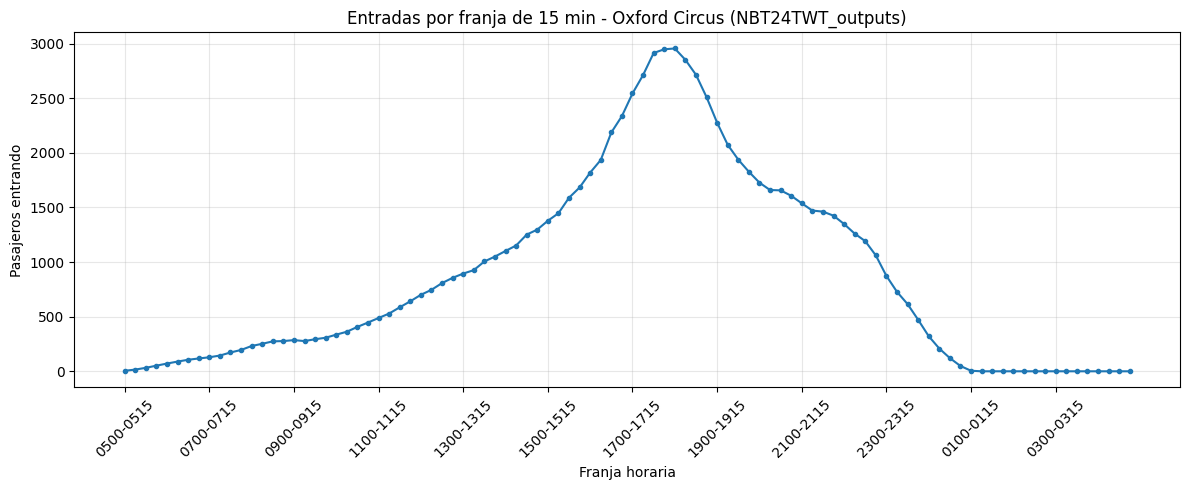

In [12]:
# AJUSTAR si quieres otra estacion. Algunas chulas:
# 'Oxford Circus', "King's Cross St. Pancras", 'Waterloo', 'Victoria',
# 'Bank and Monument', 'Liverpool Street', 'Stratford'
ESTACION = 'Oxford Circus'

fila = df_entry[df_entry[COL_ESTACION] == ESTACION]
if len(fila) == 0:
    print(f'"{ESTACION}" no encontrada. Estaciones que contienen "oxford":')
    print(df_entry[df_entry[COL_ESTACION].astype(str).str.contains('oxford', case=False, na=False)][COL_ESTACION].tolist())
else:
    serie = fila[cols_hora].iloc[0].astype(float)
    fig, ax = plt.subplots()
    ax.plot(range(len(cols_hora)), serie.values, marker='o', markersize=3)
    ax.set_title(f'Entradas por franja de 15 min - {ESTACION} ({EJEMPLO.stem})')
    ax.set_xlabel('Franja horaria')
    ax.set_ylabel('Pasajeros entrando')
    n = len(cols_hora)
    paso = max(1, n // 12)
    ax.set_xticks(range(0, n, paso))
    ax.set_xticklabels([cols_hora[i] for i in range(0, n, paso)], rotation=45)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Comparativa entre tipos de día (2024)

Misma estación, distintos día tipo (MON, TWT, FRI, SAT, SUN). Valida si separar MON de TWT tiene sentido.

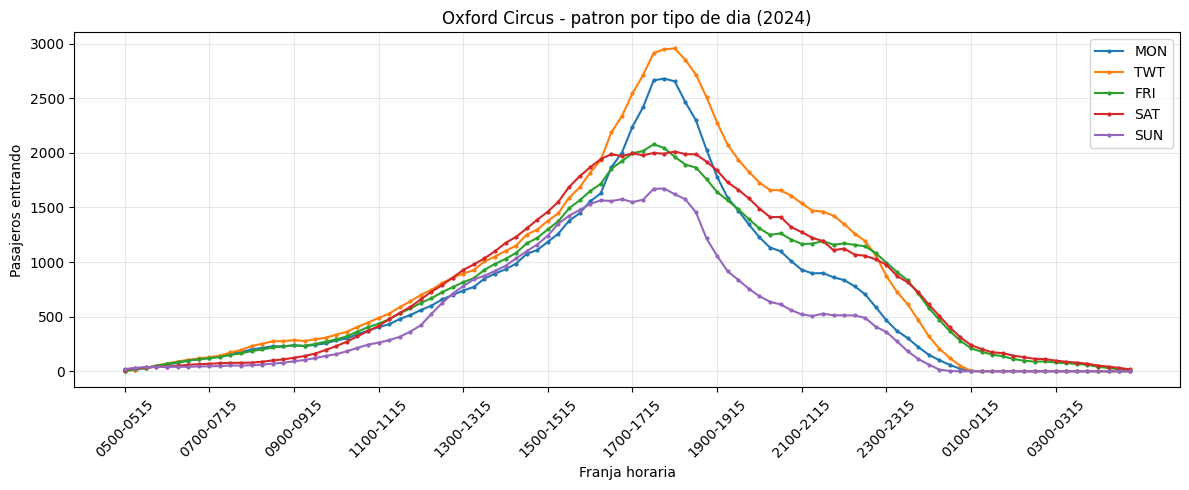

In [13]:
tipos_2024 = ['MON', 'TWT', 'FRI', 'SAT', 'SUN']
fig, ax = plt.subplots()
for tipo in tipos_2024:
    ruta = DATA_RAW / '2024' / f'NBT24{tipo}_outputs.xlsx'
    if not ruta.exists():
        print(f'Falta: {ruta.name}')
        continue
    df_t = pd.read_excel(ruta, sheet_name=HOJA_OBJETIVO, header=FILA_CABECERA)
    fila = df_t[df_t[COL_ESTACION] == ESTACION]
    if len(fila) == 0:
        print(f'  No se encontro {ESTACION} en {ruta.name}')
        continue
    cols_hora_local = [c for c in df_t.columns if patron_hora.match(str(c))]
    serie = fila[cols_hora_local].iloc[0].astype(float)
    ax.plot(range(len(cols_hora_local)), serie.values, label=tipo, marker='o', markersize=2)

ax.set_title(f'{ESTACION} - patron por tipo de dia (2024)')
ax.set_xlabel('Franja horaria')
ax.set_ylabel('Pasajeros entrando')
n = len(cols_hora)
paso = max(1, n // 12)
ax.set_xticks(range(0, n, paso))
ax.set_xticklabels([cols_hora[i] for i in range(0, n, paso)], rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparativa pre vs post COVID

Misma estacion, mismo tipo de dia laborable, distintos anios. **Plot estrella de la presentacion**.

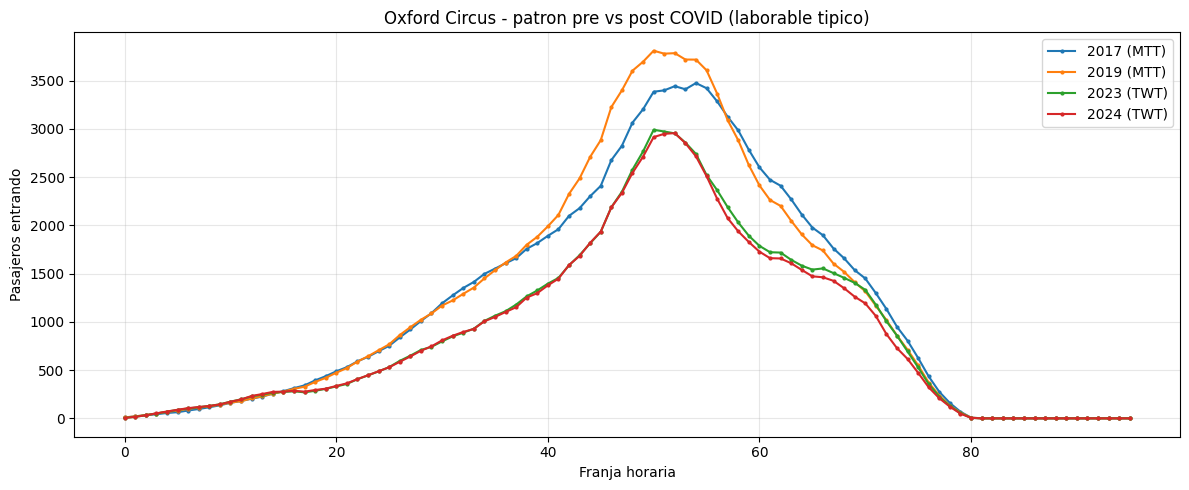

In [14]:
comparativa = {
    2017: ('MTT', '_Outputs.xlsx'),
    2019: ('MTT', '_Outputs.xlsx'),
    2023: ('TWT', '_outputs.xlsx'),
    2024: ('TWT', '_outputs.xlsx'),
}

fig, ax = plt.subplots()
for anio, (tipo, sufijo) in comparativa.items():
    nombre = f'NBT{str(anio)[2:]}{tipo}{sufijo}'
    ruta = DATA_RAW / str(anio) / nombre
    if not ruta.exists():
        print(f'Falta: {ruta}')
        continue
    try:
        df_t = pd.read_excel(ruta, sheet_name=HOJA_OBJETIVO, header=FILA_CABECERA)
    except ValueError as exc:
        print(f'Error leyendo hoja en {nombre}: {exc}')
        print(f'  Hojas disponibles: {pd.ExcelFile(ruta).sheet_names}')
        continue
    fila = df_t[df_t[COL_ESTACION] == ESTACION]
    if len(fila) == 0:
        print(f'  No se encontro {ESTACION} en {nombre}')
        continue
    cols_hora_local = [c for c in df_t.columns if patron_hora.match(str(c))]
    serie = fila[cols_hora_local].iloc[0].astype(float)
    ax.plot(range(len(cols_hora_local)), serie.values, label=f'{anio} ({tipo})', marker='o', markersize=2)

ax.set_title(f'{ESTACION} - patron pre vs post COVID (laborable tipico)')
ax.set_xlabel('Franja horaria')
ax.set_ylabel('Pasajeros entrando')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Top estaciones por volumen (TWT 2024)

,Station,total_franjas
425,Waterloo LU,147569.636333
250,Liverpool Street LU,132385.883081
233,King's Cross St. Pancras,122080.693247
414,Victoria LU,101890.606256
253,London Bridge LU,98710.702638
397,Tottenham Court Road,94897.536877
300,Paddington TfL,91185.329708
382,Stratford,85569.339949
21,Bank and Monument,85478.080353
298,Oxford Circus,84335.686654


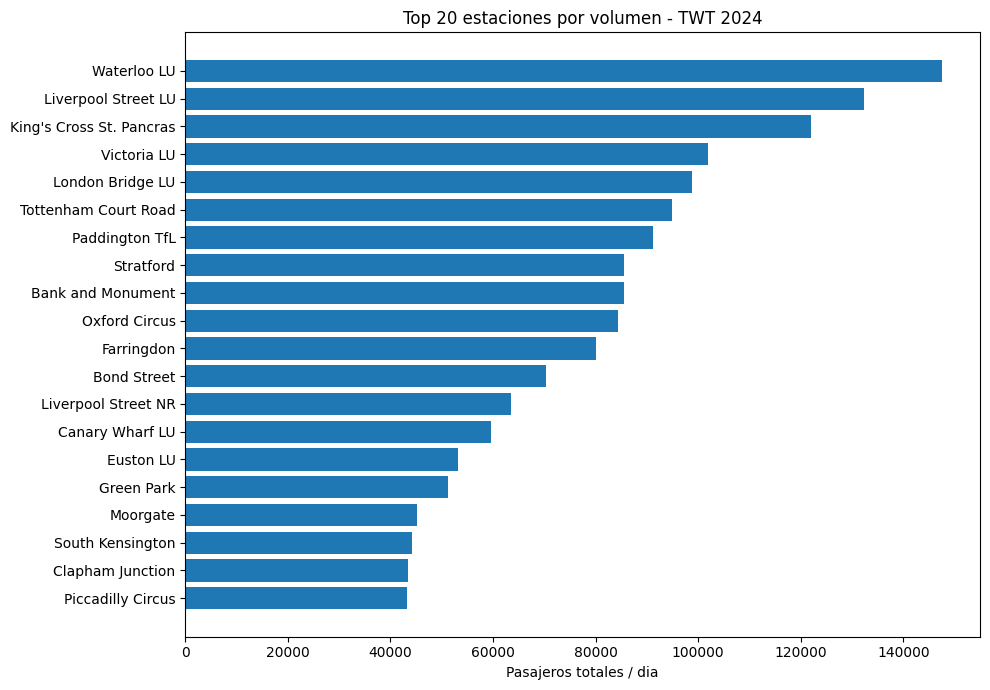

In [15]:
top20 = df_entry.nlargest(20, 'total_franjas')[[COL_ESTACION, 'total_franjas']]
display(top20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20[COL_ESTACION][::-1], top20['total_franjas'][::-1])
ax.set_xlabel('Pasajeros totales / dia')
ax.set_title('Top 20 estaciones por volumen - TWT 2024')
plt.tight_layout()
plt.show()

In [16]:
df_entry

,NLC,ASC,Station,Fare Zone,Total,Early,AM Peak,Midday,PM Peak,Evening,Late,0500-0515,0515-0530,0530-0545,0545-0600,0600-0615,0615-0630,0630-0645,0645-0700,0700-0715,0715-0730,0730-0745,0745-0800,0800-0815,0815-0830,0830-0845,0845-0900,0900-0915,0915-0930,0930-0945,...,2145-2200,2200-2215,2215-2230,2230-2245,2245-2300,2300-2315,2315-2330,2330-2345,2345-0000,0000-0015,0015-0030,0030-0045,0045-0100,0100-0115,0115-0130,0130-0145,0145-0200,0200-0215,0215-0230,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500,total_franjas
0,750,ABRd,Abbey Road,2/3,2345.280009,182.042948,646.670023,668.323560,530.264648,221.563040,96.415790,2.888792,8.350592,12.750357,18.752986,25.745682,33.224980,37.396422,42.933136,47.335227,54.193645,65.708186,68.289784,68.496366,70.868313,61.863253,51.840330,48.924392,42.033768,33.468066,...,11.008208,11.098477,11.029926,9.689882,8.888077,9.205629,7.844178,8.280411,6.463938,7.413629,5.857865,4.860611,3.107350,2.675816,3.485525e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,2345.280009
1,1404,ACCr,Acton Central,3,2761.331050,198.234129,878.501138,702.676372,682.260026,223.385872,76.273514,0.000000,0.000000,6.949193,20.123085,28.378528,35.720886,49.191123,57.871314,67.021587,75.029218,87.513128,98.579753,99.919852,88.945093,84.098491,78.528338,62.021725,51.725715,47.073548,...,13.041531,14.333273,14.070048,13.830012,11.354864,8.986202,6.012120,4.072733,2.170425,1.010542,0.403955,0.029341,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,2761.331050
2,3000,AMLr,Acton Main Line,3,5804.078852,423.492231,2176.385382,1595.639283,1227.711629,306.099393,74.750934,9.643206,17.136119,26.181957,37.591872,53.818733,76.187723,91.369317,111.563304,131.793971,162.185073,191.016765,219.346598,242.598073,250.060028,235.306233,205.596108,173.911866,142.779373,118.416922,...,16.427410,18.223783,18.350949,15.822289,11.093719,8.187028,3.073166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,5804.078852
3,500,ACTu,Acton Town,3,8221.409069,449.718828,2807.593974,2452.080379,1850.882815,489.316012,171.817062,10.216430,17.043676,28.687394,43.210581,57.887766,72.986687,96.543168,123.143127,152.749742,192.346564,248.169815,295.270611,321.855700,329.548044,314.322531,272.843545,223.371782,180.486873,148.982259,...,24.394174,22.798745,21.179946,20.501749,18.184561,15.197697,13.387431,12.091571,8.975507,6.967327,5.188493,3.604230,2.153153,1.438231,7.597913e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.462876,6.462876,6.462876,8221.409069
4,9441,ADVt,Addington Village,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,6560,CWXr,Canary Wharf EL,2,32987.481739,622.015224,5713.617511,7714.248957,13113.183951,4439.584445,1384.831651,6.215522,14.795455,34.916111,59.871303,89.127354,109.503023,140.700163,166.886293,208.250396,262.296892,337.943530,440.849212,575.658258,648.444774,680.377385,676.231981,619.152427,498.814151,413.310849,...,234.468107,220.825859,216.087272,213.069675,189.024691,165.565435,138.422987,108.798095,66.517622,39.794921,18.214738,8.510357,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,32987.48173

## 8. Conclusiones - rellenar a mano

**8.1. Estructura del archivo**
- Hojas relevantes encontradas: ...
- Hoja base: ...
- Formato (wide/long): ...
- Filas-estacion: ...
- Columnas-hora: ...

**8.2. Cobertura**
- Solo Tube o tambien DLR/Overground/Elizabeth? ...
- Como distinguirlas (ASC, Fare Zone, ...)? ...

**8.3. Calidad de datos**
- Estaciones todas-cero a filtrar: ...
- Mediana de franjas-cero (horas cierre): ...
- Sanity check total_franjas vs Total: ...

**8.4. Split train/test**
- Mi decision: ...

**8.5. Sorpresas / dudas**
- ...